cuda


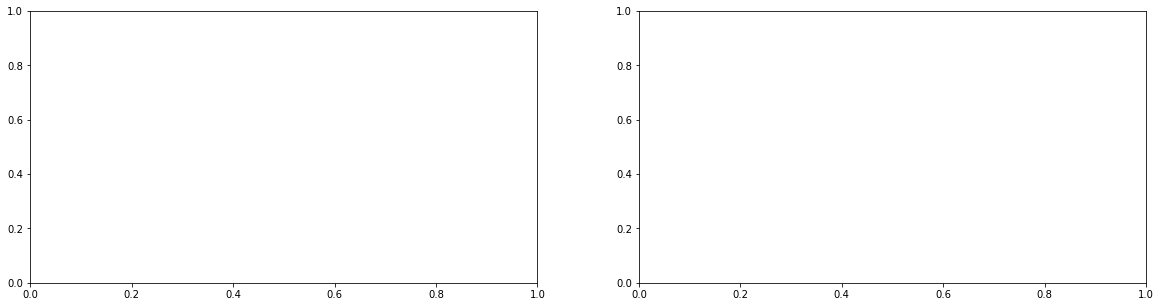

In [2]:
import os
import sys
import time
import copy
sys.path.append('../SLM/')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
import math
import random

import json

import fnmatch
import re
from itertools import product, groupby

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

device = 'cpu'
fig, ax = plt.subplots(1, 2, figsize=(20,5.0))

## Compute norms-vs-data for varying time lag $n$

In [56]:
dataset = 'tinystories'
path = f'{dataset}/correlations/'

tokenizer = 'BPE8192'
split = 'train'
prefix = f'correlations_{dataset}.{tokenizer}.{split}'

max_dist = 1025
dist = 1024
suffix = f"_d{max_dist}_t{dist}"

32768 0.0016319193 0.005452298941015522
65536 0.0011881974 0.0038396954423741414
131072 0.00086008746 0.0027012313659487805
262144 0.00067360053 0.0019493510690856881
524288 0.00048380176 0.0013793607526732315
1048576 0.00036102254 0.0009767362926111052
2097152 0.00022157349 0.0006825263510736953
4194304 0.00018525278 0.0004881827818128774
8388608 0.00010829025 0.00034052907170229076
16777216 7.487709e-05 0.0002420576694086331
33554432 5.624353e-05 0.00017153600101938392
67108864 3.677023e-05 0.00012047642918991964
134217728 2.5051617e-05 8.565586157294632e-05
268435456 2.0454694e-05 6.093916363390305e-05
[-0.49109687 -1.32717228] [-0.49817059 -0.0404391 ]
CPU times: user 2.4 s, sys: 12.7 s, total: 15.1 s
Wall time: 32.7 s


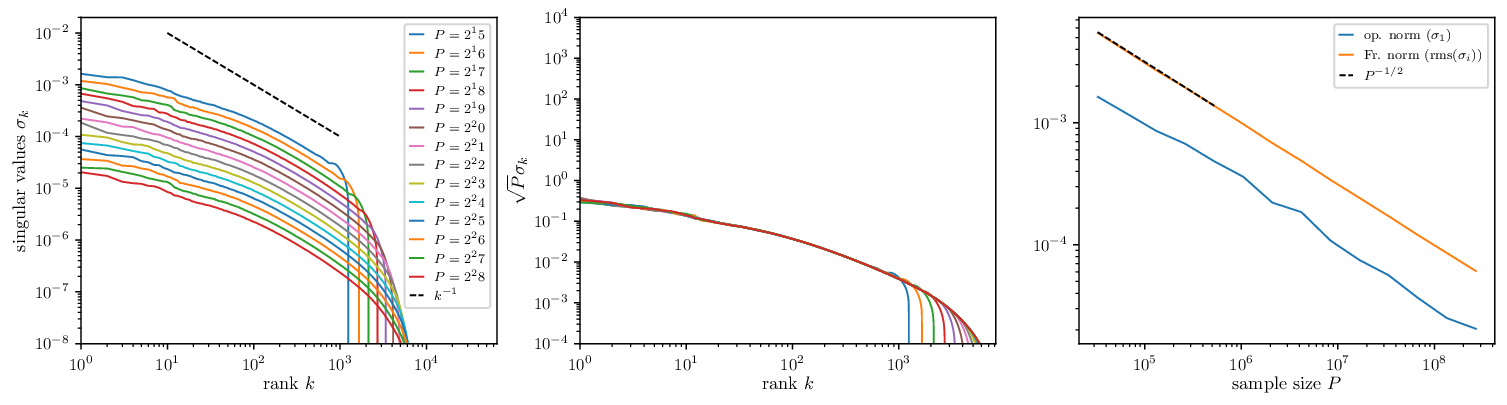

In [57]:
%%time
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig, ax = plt.subplots(1, 3, figsize=(4*3.8, 1.5*2.4), dpi=120)

p_list = [ 2**exp for exp in range(15,29)]
onorm_list = []
fnorm_list = []

for i, p in enumerate(p_list):

    covSVD = torch.load(path+f"CovSVD_{dataset}.{tokenizer}.{split}"+suffix+f"_P{p}.pt")
    S = covSVD['S']

    svals_sorted = -np.sort(-S)
    print(p, svals_sorted[0], (svals_sorted**2).sum()**.5)

    onorm_list.append(svals_sorted[0])
    fnorm_list.append((svals_sorted**2).sum()**.5)

    exponent = int(math.log(p)/math.log(2))
    ax[0].plot( 1+torch.arange(svals_sorted.size), svals_sorted, f'C{i}', label=fr'$P=2^{exponent}$')
    ax[1].plot( 1+torch.arange(svals_sorted.size), svals_sorted*p**.5, f'C{i}', label=fr'$P=2^{{exponent}}$')

gamma = 1.
G = 1e-1
ax[0].plot([1e1, 1e3], [G*1e1**(-gamma), G*1e3**(-gamma)], 'k--', label='$k^{-1}$')

ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[0].set_ylabel('singular values $\sigma_k$', fontsize=11)
ax[0].set_xlabel('rank $k$', fontsize=11)
ax[0].legend( fontsize=8, handlelength=1, loc='upper right')
ax[0].set_xlim(1,8192*8)
ax[0].set_ylim(1e-8,2e-2)

ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_ylabel('$\sqrt{P}\sigma_k$', fontsize=11)
ax[1].set_xlabel('rank $k$', fontsize=11)
ax[1].set_xlim(1,8192)
ax[1].set_ylim(1e-4,1e4)

ax[2].plot(p_list, onorm_list, f'C0', label='op. norm ($\sigma_1$)')
ax[2].plot(p_list, fnorm_list, f'C1', label='Fr. norm ($\mathrm{rms}(\sigma_i)$)')
ax[2].plot([p for p in p_list[:5]], [p**(-.5) for p in p_list[:5]] , 'k--', label=r'$P^{-1/2}')
fit_f = np.polyfit(np.log(np.array(p_list[-5:])), np.log(np.array(fnorm_list[-5:])), 1)
fit_o = np.polyfit(np.log(np.array(p_list[-5:])), np.log(np.array(onorm_list[-5:])), 1)
print(fit_o, fit_f)
# ax[1].plot(p_list, [o*math.sqrt(vocab_size) for o in onorm_list], f'C2', label='scaled op. norm')
ax[2].set_yscale('log')
ax[2].set_xscale('log')
ax[2].set_xlabel('sample size $P$', fontsize=11)
ax[2].legend( fontsize=8, handlelength=1)

In [ ]:
# fig.savefig(f"CovSVD_tinystories.BPE{vocab_size}.{split}_d{max_dist}_t{dist}.pdf")

In [58]:
torch.save(
    {'data': p_list, 'op': onorm_list, 'fro': fnorm_list},
    f"tinystories/correlations/"+f"corr-norms-v-data_tinystories.BPE8192_nmax{max_dist}_n{dist}.pt"
)

# norm-v-time plot varying #(data)

14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
torch.Size([18, 14])
CPU times: user 203 ms, sys: 3.81 ms, total: 207 ms
Wall time: 206 ms


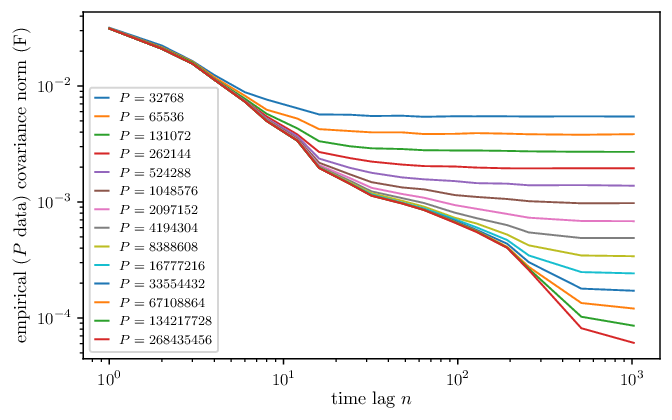

In [15]:
%%time
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig, ax = plt.subplots(1, 1, figsize=(1.5*3.8, 1.5*2.4), dpi=120)

n_list = [ 1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 64, 96, 128, 192, 256, 512, 1024]
max_n = 1025
norm_v_p = []

for i, n in enumerate(n_list):

    corr = torch.load(f"tinystories/correlations/"+f"corr-norms-v-data_tinystories.BPE8192_nmax{max_n}_n{n}.pt")
    norm_v_p.append(corr['fro'])
    p_list = corr['data']

norm_v_p = torch.tensor(norm_v_p)
print(norm_v_p.size())

for i, p in enumerate(p_list):
    ax.plot( n_list, norm_v_p[:,i], label=fr'$P={p}$')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel(r'empirical ($P$ data) covariance norm (F)', fontsize=11)
ax.set_xlabel(r'time lag $n$', fontsize=11)
ax.legend( fontsize=8, handlelength=1, loc='lower left')
# ax[0].set_xlim(1,8192*8)
# ax[0].set_ylim(1e-8,1e-1)
fig.tight_layout()

In [16]:
fig.savefig(f'tinystories/'+f'C_v_n_var_p_tinystories.BPE8192.pdf',  bbox_inches="tight")

12 torch.Size([4, 128])
65536 tensor(0.0012) tensor(0.0039)
262144 tensor(0.0006) tensor(0.0020)
1048576 tensor(0.0005) tensor(0.0011)
4194304 tensor(0.0004) tensor(0.0007)
16777216 tensor(0.0004) tensor(0.0006)
67108864 tensor(0.0004) tensor(0.0006)
268435456 tensor(0.0004) tensor(0.0006)


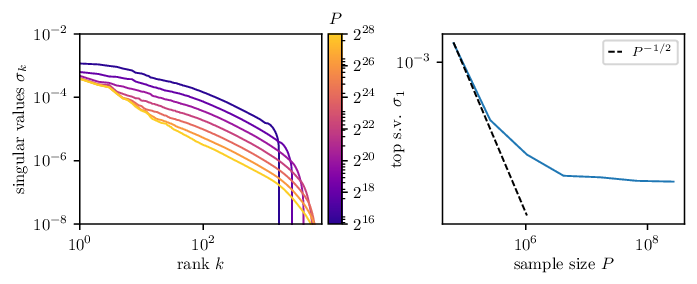

In [23]:
import matplotlib.ticker as mticker

matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
# fig, ax = plt.subplots(1, 2, figsize=(2*3.8, 1*3.4), dpi=120)
fig = plt.figure(figsize=(1*2.8, 1*2.2), dpi=120)  # can be same for all
L, B, W, H = 0.18, 0.18, 0.72, 0.72
G = 0.18          # gap between the two plot boxes
ax0 = fig.add_axes([L,           B, W, H])
# ax1 = fig.add_axes([L + W + G,   B, W, H])
# ax = np.array([
#     fig.add_axes(L, B, W, H),
#     fig.add_axes(2*L+W, B, W, H),
# ])
# ax  = fig.add_axes([L, B, W, H])                # <-- plot box is fixed
# ax  = fig.add_axes([L, B, W, H])                # <-- plot box is fixed

T = 128
depth = 12


results = torch.load(f"tinystories/learning-curves/ngrams_tinystories.BPE8192_T{T}_d{depth}.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

n_list = []
H_list = []
alpha_list = []

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=2**16, vmax=2**28)

# ax0.plot([p for p in p_list], [loss[n-1] for loss in ngrams_list], color=cmap(norm(n)), marker='.', label=f'n={n+1}')
# ax0.plot(p_list, [A*p**(-alpha)+C for p in p_list], color=cmap(norm(n)), linestyle='dashed', label=fr'$H_1={C}$')
# ax1.plot([p for p in p_list], [loss[n-1]-C for loss in ngrams_list], color=cmap(norm(n)), marker='.', label=f'n={n+1}')
# ax1.plot([1e6,1e9],[A*1e6**-(alpha),A*1e9**-(alpha)],color=cmap(norm(n)), linestyle='dashed', label=r'$\alpha=$'+'{:04.3f}'.format(alpha))
# n_list.append(n)
# H_list.append(C)
# alpha_list.append(alpha)

vocab_size = 8192
split = 'train'
max_dist = 1025
path = "tinystories/correlations/"
prefix = f"correlations_tinystories.BPE{vocab_size}.{split}_d{max_dist}"


dist = 128
p_list = [ 2**exp for exp in range(16,29,2)]
onorm_list = []
fnorm_list = []

for i, p in enumerate(p_list):

    spectrum = torch.load(path + f"CovSVD_tinystories.BPE8192.train_d{max_dist}_t{dist}_P{p}.pt")
    svals = spectrum['S']
    svals_sorted, indices_sorted = torch.sort(svals, descending=True)
    onorm_list.append(svals_sorted[0])
    fnorm_list.append((svals_sorted**2).sum()**.5)
    print(p, svals_sorted[0], (svals_sorted**2).sum()**.5)
    exponent = int(math.log(p)/math.log(2))
    ax0.plot( 1+torch.arange(svals.size(0)), svals_sorted, color=cmap(norm(p)), label=fr'$P=2^{{{exponent}}}$')


ax0.set_xscale('log')
ax0.set_yscale('log')
ax0.set_ylabel('singular values $\sigma_k$', fontsize=10)
ax0.set_xlabel('rank $k$', fontsize=10)
ax0.set_xlim(1,8192)
ax0.set_ylim(1e-8,1e-2)

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy
CB_W  = 0.04
CB_PAD = 0.02
want_cbar = True
if want_cbar:
    cax = fig.add_axes([L + W + CB_PAD, B, CB_W, H])  # same height as ax
    cbar = fig.colorbar(sm, cax=cax)
    cbar.ax.set_title(r"$P$", fontsize=10, pad=6)
ticks = 2 ** np.arange(
    16,
    29,
    2
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])
# ticks  = [2, 3, 4]
# labels = [ "2", "3", "4"]  # must match length/order
# ax0.set_yticks(ticks)
# ax0.set_yticklabels(labels)
# ax0.yaxis.set_minor_locator(mticker.NullLocator())

# ax1.plot([1e6,1e9],[30*1e6**-(.34/(2*.88)),30*1e9**-(.34/(2*.88))],'r--')
# ax1.set_xscale('log')
# ax1.set_yscale('log')
# ax1.set_ylabel(r'$\mathcal{L}_{n}-H_{n}$', fontsize=10, labelpad=-0)
# ax1.set_xlabel(r'$P$', fontsize=10)

# ticks  = [0.1, 1]
# labels = [ ".1", "1"]  # must match length/order
# ax1.set_yticks(ticks)
# ax1.set_yticklabels(labels)
# ax1.yaxis.set_minor_locator(mticker.NullLocator())

ax1 = fig.add_axes([L + W + G + 4*CB_W + CB_PAD,   B, W, H])
ax1.plot(p_list, onorm_list, f'C0')
# ax1.plot(p_list, fnorm_list, f'C1', label='Fr. norm ($\mathrm{rms}(\sigma_i)$)')
ax1.plot([p for p in p_list[:3]], [.3*p**(-.5) for p in p_list[:3]] , 'k--', label=r'$P^{-1/2}$')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel(r'top s.v. $\sigma_1$', fontsize=10, labelpad=-5)
ax1.set_xlabel(r'sample size $P$', fontsize=10)
ax1.legend(fontsize=8, handlelength=1)
ax1.yaxis.set_minor_locator(mticker.NullLocator())
# ticks  = [0.2, 0.3]
# labels = [ ".2", ".3"]  # must match length/order
# ax2.set_yticks(ticks)
# ax2.set_yticklabels(labels)
# ax2.yaxis.set_minor_locator(mticker.NullLocator())